# Building Artificial Neural Network

- MNIST Dataset

### Step 1: Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

### Step 2: Load and preprocess the MNIST dataset from mnist.csv

In [2]:
# Load the Dataset
mnist_df = pd.read_csv('mnist.csv')

In [3]:
# Split the dataset into features (pixels) and labels (target)
features = mnist_df.drop('label', axis=1)
labels = mnist_df['label']

In [4]:
# Normalize pixel values to be in the range [0, 1]
features = features / 255.0

In [5]:
# Convert features and labels to NumPy arrays
features = np.array(features)
labels = np.array(labels)

In [6]:
# Reshape the features to match the expected input shape
features = features.reshape(-1, 28, 28)

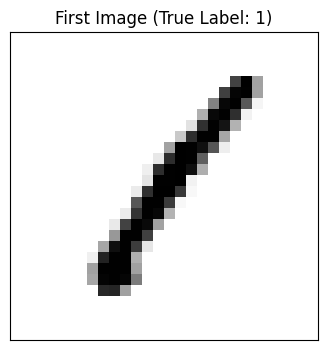

In [7]:
# Visualise the Image data
plt.figure(figsize=(4, 4))
plt.imshow(features[0], cmap=plt.cm.binary)
plt.title(f"First Image (True Label: {labels[0]})")
plt.show()

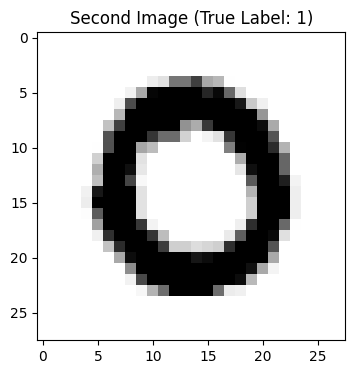

In [8]:
# Visualise the Image data
plt.figure(figsize=(4, 4))
plt.imshow(features[1], cmap=plt.cm.binary)
plt.title(f"Second Image (True Label: {labels[0]})")
plt.show()

In [9]:
# Reshape the labels to be one-dimensional
labels = labels.reshape(-1)

### Step 3: Build the ANN model

In [10]:
model = keras.Sequential([

    # Flatten the 28x28 images to a 1D array
    keras.layers.Flatten(input_shape=(28, 28)),

    # Fully connected layer with 128 neurons and ReLU activation
    keras.layers.Dense(128, activation='relu'),

    # Dropout layer to prevent overfitting
    keras.layers.Dropout(0.2),

    # Output layer with 10 neurons (for 0-9 digits) and softmax activation
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
# Visualise the Network
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Step 4: Compile the model

In [13]:
# Step 4: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Cross-entropy loss for classification
    metrics=['accuracy']
    )

### Step 5: Train the model

In [14]:
# Model Training
history = model.fit(features, labels, epochs=5)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9029 - loss: 0.3356
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9532 - loss: 0.1595
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9632 - loss: 0.1197
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9711 - loss: 0.0970
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9737 - loss: 0.0817


### Plotting Training History

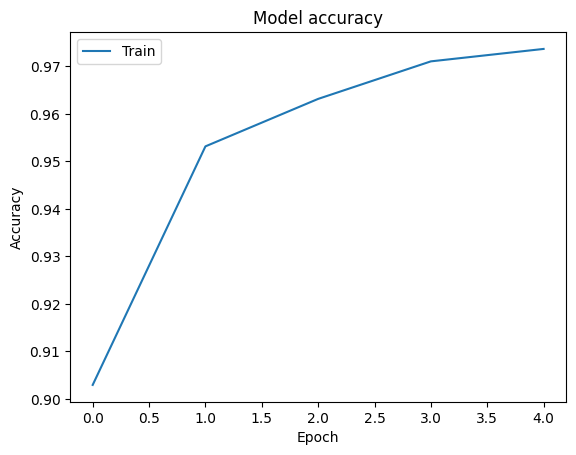

In [15]:
# Plot training accuracy values
plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

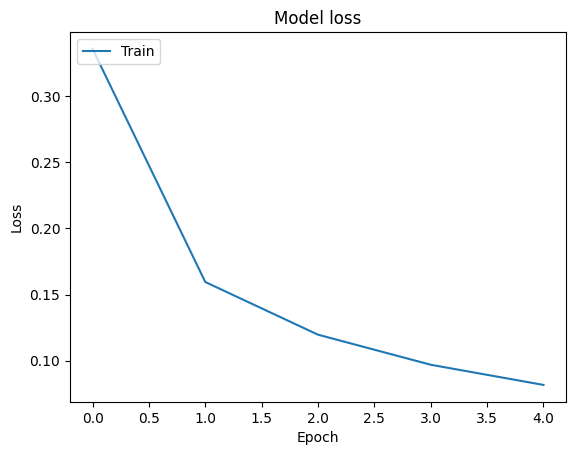

In [16]:
# Plot training loss values
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()

### Step 6: Make predictions

In [19]:
 # Use the same dataset for predictions (not recommended for real-world use)
predictions = model.predict(features)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 961us/step


### Classification Metrics and Report

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
# Convert predictions to predicted labels
predicted_labels = np.argmax(predictions, axis=1)

In [21]:
# Print classification report
print("Classification Report:")
print(classification_report(labels, predicted_labels))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4132
           1       0.99      0.99      0.99      4684
           2       0.99      0.99      0.99      4177
           3       0.97      0.99      0.98      4351
           4       0.99      0.98      0.99      4072
           5       0.99      0.97      0.98      3795
           6       1.00      0.99      0.99      4137
           7       0.99      0.99      0.99      4401
           8       0.99      0.98      0.98      4063
           9       0.96      0.99      0.98      4188

    accuracy                           0.99     42000
   macro avg       0.99      0.99      0.99     42000
weighted avg       0.99      0.99      0.99     42000



In [22]:
# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(labels, predicted_labels))

Confusion Matrix:
[[4112    0    3    3    2    0    4    0    4    4]
 [   0 4639    7   11    3    0    2    6   10    6]
 [   4    1 4116   23    7    0    3   14    4    5]
 [   2    0    6 4304    0    8    0    6   10   15]
 [   3    3    2    0 3998    0    5    3    2   56]
 [   3    1    0   54    0 3694    4    2   10   27]
 [   7    4    0    0    4    9 4112    0    1    0]
 [   1    7    8    5    4    1    0 4359    0   16]
 [   2   10    2   36    8    7    1    5 3964   28]
 [   5    0    0    6   10    4    0   13    1 4149]]


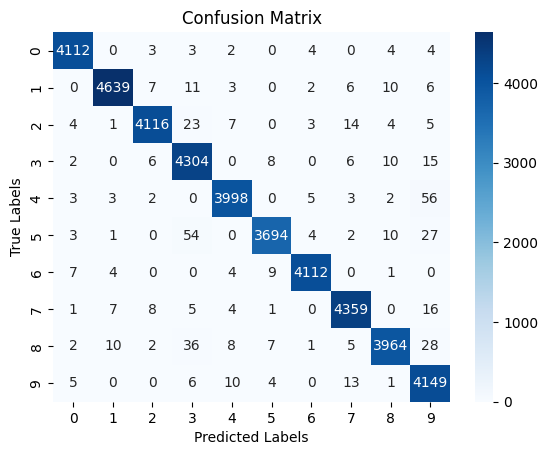

In [24]:
import seaborn as sns

sns.heatmap(confusion_matrix(labels, predicted_labels), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### Step 7: Visualize the results

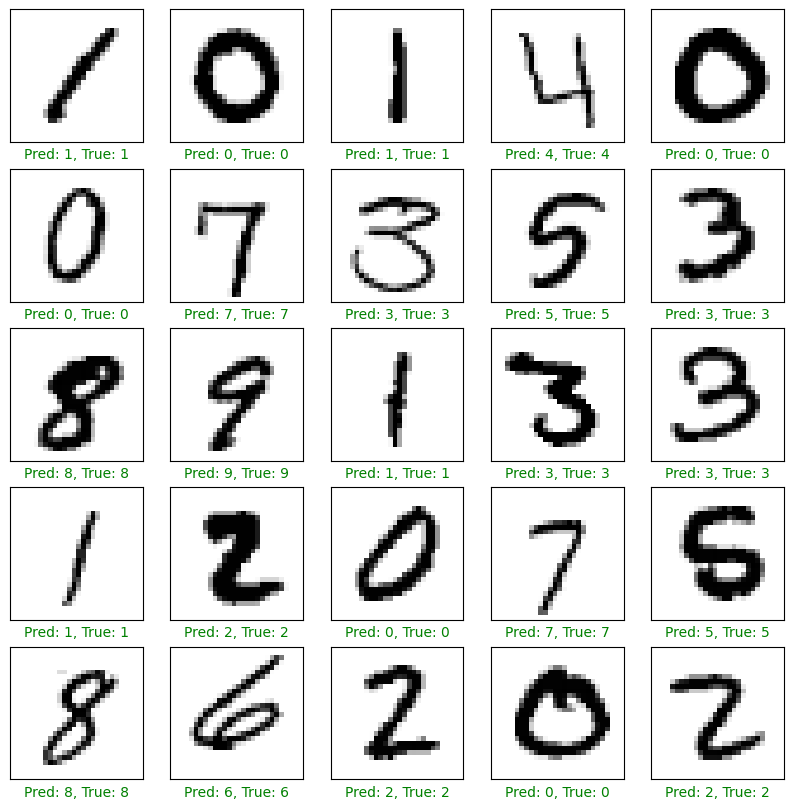

In [26]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(features[i], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[i])
    true_label = labels[i]
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'
    plt.xlabel(f"Pred: {predicted_label}, True: {true_label}", color=color)
plt.show()